**Sathish Babu Nuthi_BA74061_Assignemnt 1**



ADDING LIBRARIES AND LOADING THE DATA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [ ]:
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension), dtype=np.float32)
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

x_train_vec = vectorize_sequences(x_train, num_words)
x_test_vec  = vectorize_sequences(x_test, num_words)

y_train = np.asarray(y_train).astype("float32")
y_test  = np.asarray(y_test).astype("float32")

val_size = 10000
x_val = x_train_vec[:val_size]
partial_x_train = x_train_vec[val_size:]

y_val = y_train[:val_size]
partial_y_train = y_train[val_size:]

print("partial_x_train:", partial_x_train.shape)
print("x_val:", x_val.shape)
print("x_test_vec:", x_test_vec.shape)

partial_x_train: (15000, 10000)
x_val: (10000, 10000)
x_test_vec: (25000, 10000)


Q1.You used two hidden layers. Try using one or three hidden layers and see how doing so
affects validation and test accuracy.

I have used one hidden layer

Training: 1 Hidden Layer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7238 - loss: 0.5812 - val_accuracy: 0.8653 - val_loss: 0.3994
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8949 - loss: 0.3485 - val_accuracy: 0.8802 - val_loss: 0.3305
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9170 - loss: 0.2707 - val_accuracy: 0.8850 - val_loss: 0.2994
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9290 - loss: 0.2255 - val_accuracy: 0.8871 - val_loss: 0.2837
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9389 - loss: 0.1954 - val_accuracy: 0.8870 - val_loss: 0.2797
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9468 - loss: 0.1734 - val_accuracy: 0.8861 - val_loss: 0.2773
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9527 - loss: 0.1556 - val_accuracy: 0.8854 - val_loss: 0.2787
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9585 - loss: 0.1402 - val_accuracy: 0.8834 - v

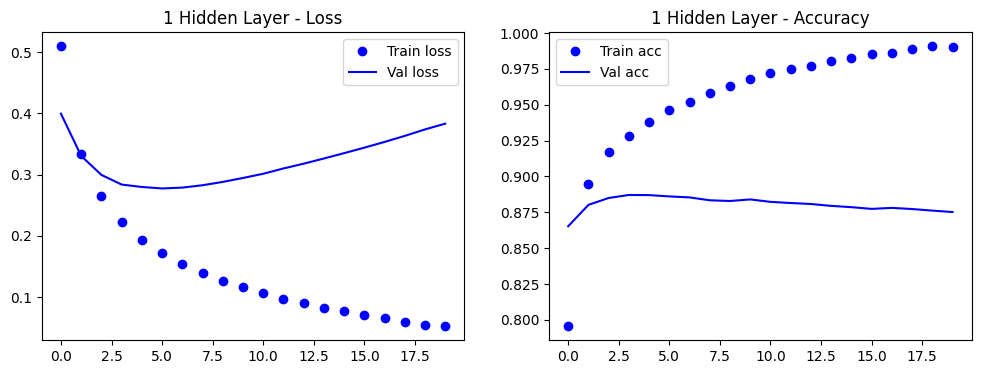

In [ ]:
model_1layer = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(1, activation="sigmoid")
])

model_1layer.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: 1 Hidden Layer")
history_1layer = model_1layer.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)


best_val_acc_1 = max(history_1layer.history["val_accuracy"])
best_val_loss_1 = min(history_1layer.history["val_loss"])
best_epoch_1 = history_1layer.history["val_accuracy"].index(best_val_acc_1) + 1
print(f"\nBest Val Acc: {best_val_acc_1:.4f} (Epoch {best_epoch_1})")
print(f"Best Val Loss: {best_val_loss_1:.4f}")


test_loss_1, test_acc_1 = model_1layer.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc: {test_acc_1:.4f}")
print(f"Test Loss: {test_loss_1:.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_1layer.history["loss"], "bo", label="Train loss")
plt.plot(history_1layer.history["val_loss"], "b", label="Val loss")
plt.title("1 Hidden Layer - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_1layer.history["accuracy"], "bo", label="Train acc")
plt.plot(history_1layer.history["val_accuracy"], "b", label="Val acc")
plt.title("1 Hidden Layer - Accuracy")
plt.legend()

plt.show()

I have tried using Two Hidden layers

Training: 2 Hidden Layers
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6946 - loss: 0.5923 - val_accuracy: 0.8657 - val_loss: 0.3800
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8927 - loss: 0.3248 - val_accuracy: 0.8837 - val_loss: 0.3066
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9230 - loss: 0.2365 - val_accuracy: 0.8876 - val_loss: 0.2817
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9377 - loss: 0.1883 - val_accuracy: 0.8872 - val_loss: 0.2783
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9532 - loss: 0.1529 - val_accuracy: 0.8886 - val_loss: 0.2806
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9582 - loss: 0.1323 - val_accuracy: 0.8853 - val_loss: 0.2912
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9656 - loss: 0.1116 - val_accuracy: 0.8861 - val_loss: 0.3023
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9735 - loss: 0.0936 

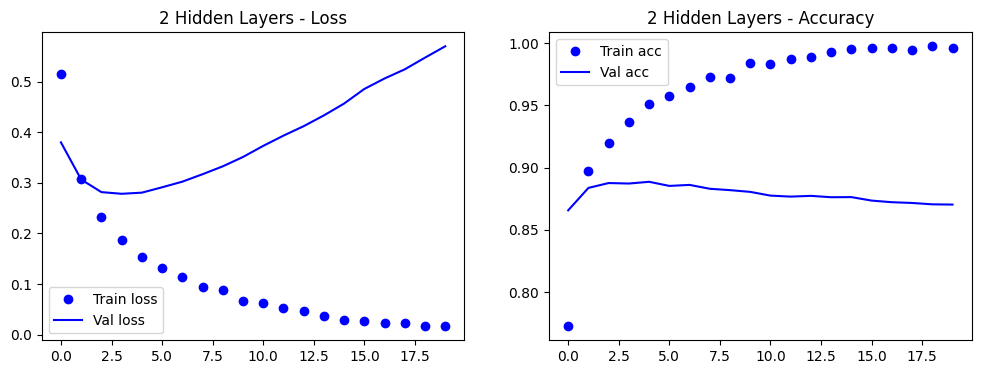

In [ ]:
model_2layer = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_2layer.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: 2 Hidden Layers")
history_2layer = model_2layer.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)


best_val_acc_2 = max(history_2layer.history["val_accuracy"])
best_val_loss_2 = min(history_2layer.history["val_loss"])
best_epoch_2 = history_2layer.history["val_accuracy"].index(best_val_acc_2) + 1
print(f"\nBest Val Acc: {best_val_acc_2:.4f} (Epoch {best_epoch_2})")
print(f"Best Val Loss: {best_val_loss_2:.4f}")


test_loss_2, test_acc_2 = model_2layer.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc: {test_acc_2:.4f}")
print(f"Test Loss: {test_loss_2:.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_2layer.history["loss"], "bo", label="Train loss")
plt.plot(history_2layer.history["val_loss"], "b", label="Val loss")
plt.title("2 Hidden Layers - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_2layer.history["accuracy"], "bo", label="Train acc")
plt.plot(history_2layer.history["val_accuracy"], "b", label="Val acc")
plt.title("2 Hidden Layers - Accuracy")
plt.legend()

plt.show()

I have tried using Three Hidden layers


Training: 3 Hidden Layers
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7009 - loss: 0.6111 - val_accuracy: 0.8653 - val_loss: 0.3942
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8878 - loss: 0.3410 - val_accuracy: 0.8769 - val_loss: 0.3126
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9166 - loss: 0.2425 - val_accuracy: 0.8891 - val_loss: 0.2809
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9342 - loss: 0.1905 - val_accuracy: 0.8863 - val_loss: 0.2800
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9526 - loss: 0.1492 - val_accuracy: 0.8849 - val_loss: 0.2860
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9634 - loss: 0.1221 - val_accuracy: 0.8832 - val_loss: 0.2982
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9717 - loss: 0.1027 - val_accuracy: 0.8812 - val_loss: 0.3145
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9749 - loss: 0.0885 

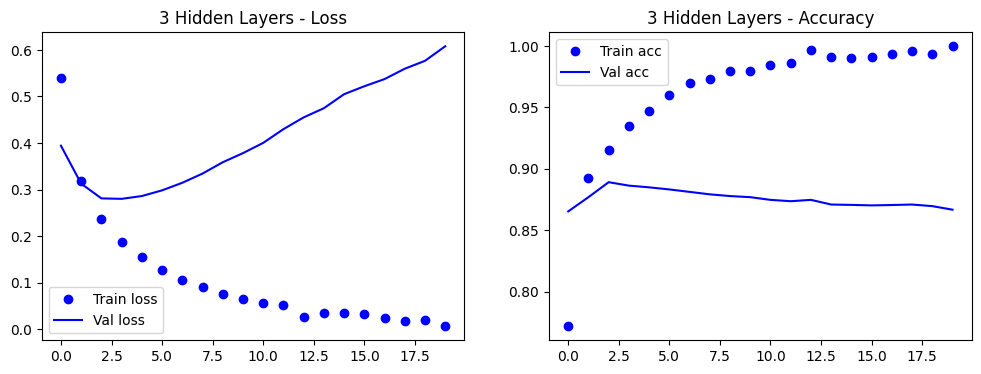

In [ ]:
model_3layer = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_3layer.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: 3 Hidden Layers")
history_3layer = model_3layer.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)


best_val_acc_3 = max(history_3layer.history["val_accuracy"])
best_val_loss_3 = min(history_3layer.history["val_loss"])
best_epoch_3 = history_3layer.history["val_accuracy"].index(best_val_acc_3) + 1
print(f"\nBest Val Acc: {best_val_acc_3:.4f} (Epoch {best_epoch_3})")
print(f"Best Val Loss: {best_val_loss_3:.4f}")


test_loss_3, test_acc_3 = model_3layer.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc: {test_acc_3:.4f}")
print(f"Test Loss: {test_loss_3:.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_3layer.history["loss"], "bo", label="Train loss")
plt.plot(history_3layer.history["val_loss"], "b", label="Val loss")
plt.title("3 Hidden Layers - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_3layer.history["accuracy"], "bo", label="Train acc")
plt.plot(history_3layer.history["val_accuracy"], "b", label="Val acc")
plt.title("3 Hidden Layers - Accuracy")
plt.legend()

plt.show()

Question 1: Summary Comparison (1 vs 2 vs 3 Hidden Layers)



Q1 Summary (sorted by Best Validation Accuracy) 
          model  best_val_acc  best_epoch  test_acc
3 hidden layers        0.8891           3   0.85408
2 hidden layers        0.8886           5   0.85572
 1 hidden layer        0.8871           4   0.86468


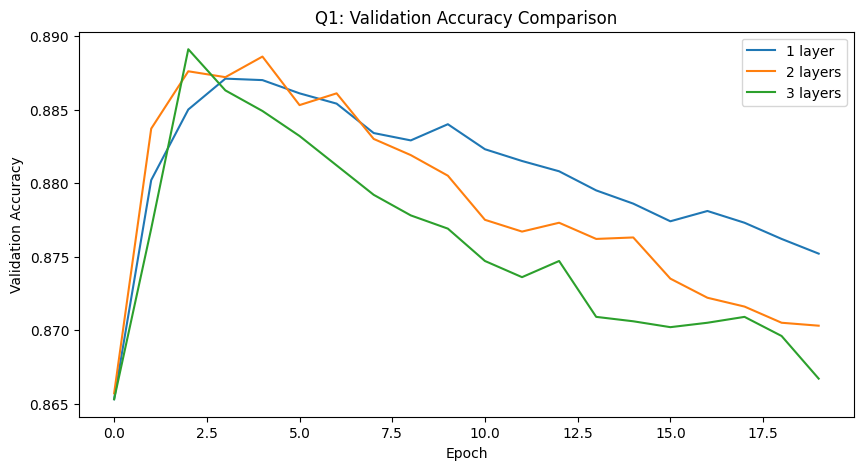

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

q1_summary = pd.DataFrame([
    {"model": "1 hidden layer", "best_val_acc": best_val_acc_1, "best_epoch": best_epoch_1, "test_acc": test_acc_1},
    {"model": "2 hidden layers", "best_val_acc": best_val_acc_2, "best_epoch": best_epoch_2, "test_acc": test_acc_2},
    {"model": "3 hidden layers", "best_val_acc": best_val_acc_3, "best_epoch": best_epoch_3, "test_acc": test_acc_3},
]).sort_values("best_val_acc", ascending=False)

print("\nQ1 Summary (sorted by Best Validation Accuracy) ")
print(q1_summary.to_string(index=False))


plt.figure(figsize=(10,5))
plt.plot(history_1layer.history["val_accuracy"], label="1 layer")
plt.plot(history_2layer.history["val_accuracy"], label="2 layers")
plt.plot(history_3layer.history["val_accuracy"], label="3 layers")
plt.title("Q1: Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


Q2 :Try using layers with more hidden units or fewer hidden units: 32 units, 64 units, and so
on.

firstly i have used 32 hiddenlayers

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: 32 Hidden Units
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6845 - loss: 0.5925 - val_accuracy: 0.8676 - val_loss: 0.3702
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8967 - loss: 0.3171 - val_accuracy: 0.8862 - val_loss: 0.2988
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9200 - loss: 0.2305 - val_accuracy: 0.8807 - val_loss: 0.2959
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9377 - loss: 0.1870 - val_accuracy: 0.8876 - val_loss: 0.2775
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9413 - loss: 0.1616 - val_accuracy: 0.8866 - val_loss: 0.2826
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9593 - loss: 0.1287 - val_accuracy: 0.8851 - val_loss: 0.2938
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.9645 - loss: 0.1093 - val_accuracy: 0.8833 - val_loss: 0.3073
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9732 - loss: 0.0909 

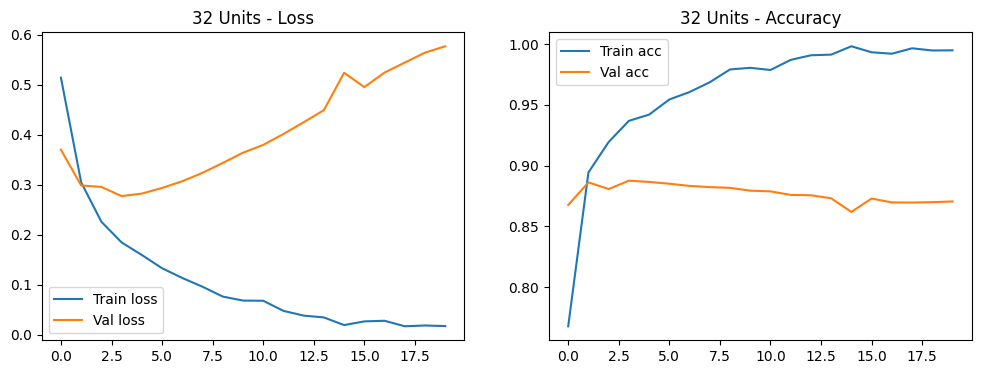

In [ ]:
model_32 = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(10000,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_32.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: 32 Hidden Units")
history_32 = model_32.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

best_val_acc_32 = max(history_32.history["val_accuracy"])
best_epoch_32 = history_32.history["val_accuracy"].index(best_val_acc_32) + 1
print(f"\nBest Val Acc (32 units): {best_val_acc_32:.4f} (Epoch {best_epoch_32})")

test_loss_32, test_acc_32 = model_32.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc (32 units): {test_acc_32:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_32.history["loss"], label="Train loss")
plt.plot(history_32.history["val_loss"], label="Val loss")
plt.title("32 Units - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_32.history["accuracy"], label="Train acc")
plt.plot(history_32.history["val_accuracy"], label="Val acc")
plt.title("32 Units - Accuracy")
plt.legend()

plt.show()

**I have Used 64 Hidden layers**

Training: 64 Hidden Units
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6501 - loss: 0.6001 - val_accuracy: 0.8718 - val_loss: 0.3447
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8796 - loss: 0.3179 - val_accuracy: 0.8880 - val_loss: 0.2848
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9147 - loss: 0.2299 - val_accuracy: 0.8866 - val_loss: 0.2781
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9377 - loss: 0.1761 - val_accuracy: 0.8854 - val_loss: 0.2770
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9521 - loss: 0.1416 - val_accuracy: 0.8848 - val_loss: 0.2943
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9549 - loss: 0.1275 - val_accuracy: 0.8840 - val_loss: 0.3071
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9649 - loss: 0.1001 - val_accuracy: 0.8833 - val_loss: 0.3197
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9741 - loss: 0.0788

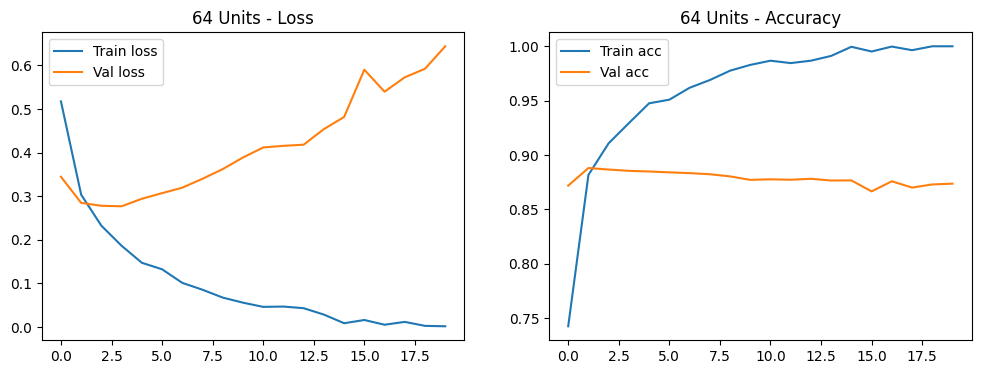

In [ ]:
model_64 = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(10000,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_64.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: 64 Hidden Units")
history_64 = model_64.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

best_val_acc_64 = max(history_64.history["val_accuracy"])
best_epoch_64 = history_64.history["val_accuracy"].index(best_val_acc_64) + 1
print(f"\nBest Val Acc (64 units): {best_val_acc_64:.4f} (Epoch {best_epoch_64})")

test_loss_64, test_acc_64 = model_64.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc (64 units): {test_acc_64:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_64.history["loss"], label="Train loss")
plt.plot(history_64.history["val_loss"], label="Val loss")
plt.title("64 Units - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_64.history["accuracy"], label="Train acc")
plt.plot(history_64.history["val_accuracy"], label="Val acc")
plt.title("64 Units - Accuracy")
plt.legend()

plt.show()

I have used 16 hidden layers

Training: 16 Hidden Units
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7086 - loss: 0.5890 - val_accuracy: 0.8672 - val_loss: 0.3792
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8870 - loss: 0.3344 - val_accuracy: 0.8847 - val_loss: 0.3080
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9217 - loss: 0.2383 - val_accuracy: 0.8887 - val_loss: 0.2815
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9380 - loss: 0.1887 - val_accuracy: 0.8895 - val_loss: 0.2750
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9534 - loss: 0.1523 - val_accuracy: 0.8861 - val_loss: 0.2800
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9620 - loss: 0.1304 - val_accuracy: 0.8881 - val_loss: 0.2873
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9684 - loss: 0.1091 - val_accuracy: 0.8840 - val_loss: 0.2999
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9744 - loss: 0.0911 

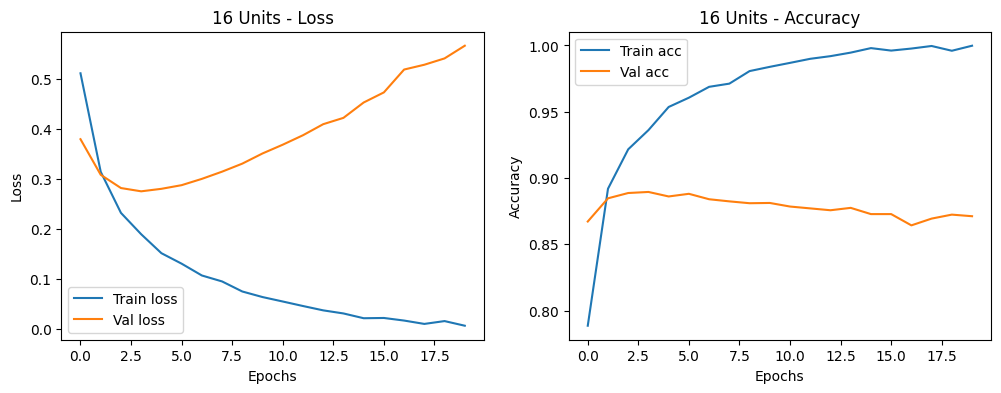

In [ ]:
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


model_16 = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),

    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


model_16.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: 16 Hidden Units")
history_16 = model_16.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)


best_val_acc_16 = max(history_16.history["val_accuracy"])
best_epoch_16 = history_16.history["val_accuracy"].index(best_val_acc_16) + 1
print(f"\nBest Val Acc (16 units): {best_val_acc_16:.4f} (Epoch {best_epoch_16})")


test_loss_16, test_acc_16 = model_16.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc (16 units): {test_acc_16:.4f}")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_16.history["loss"], label="Train loss")
plt.plot(history_16.history["val_loss"], label="Val loss")
plt.title("16 Units - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_16.history["accuracy"], label="Train acc")
plt.plot(history_16.history["val_accuracy"], label="Val acc")
plt.title("16 Units - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Accuracy Comparision for Hidden layers


In [ ]:
import pandas as pd

q2_summary = pd.DataFrame([

   {"units": 16, "best_val_acc": best_val_acc_16, "test_acc": test_acc_16},
   {"units": 32, "best_val_acc": best_val_acc_32, "test_acc": test_acc_32},
    {"units": 64, "best_val_acc": best_val_acc_64, "test_acc": test_acc_64},
]).sort_values("best_val_acc", ascending=False)

print("\n Question 2 Summary  ")
print(q2_summary.to_string(index=False))



 Question 2 Summary  
 units  best_val_acc  test_acc
    16        0.8895   0.85984
    64        0.8880   0.86280
    32        0.8876   0.85816


**3.Try using the mse loss function instead of binary_crossentropy.**

since there is no much difference between both best value and test values of 32 and 16 hidden layers, I Have choosen continue with 16 layers as it need less no.of executions


Training: MSE Loss


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6944 - loss: 0.2128 - val_accuracy: 0.8622 - val_loss: 0.1317
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8866 - loss: 0.1131 - val_accuracy: 0.8819 - val_loss: 0.1014
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9116 - loss: 0.0827 - val_accuracy: 0.8876 - val_loss: 0.0904
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9257 - loss: 0.0665 - val_accuracy: 0.8868 - val_loss: 0.0871
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9424 - loss: 0.0551 - val_accuracy: 0.8865 - val_loss: 0.0845
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9498 - loss: 0.0477 - val_accuracy: 0.8855 - val_loss: 0.0839
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9591 - loss: 0.0410 - val_accuracy: 0.8840 - val_loss: 0.0842
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9613 - loss: 0.0379 - val_accuracy: 0.8826 - v

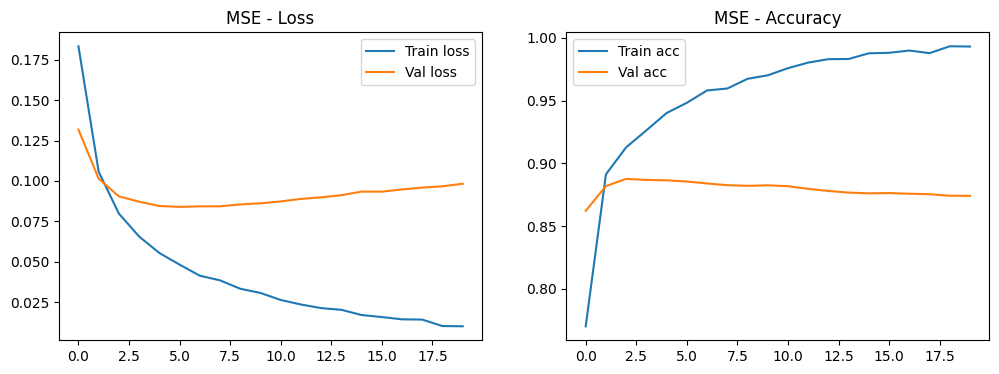

In [ ]:
model_mse = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_mse.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["accuracy"]
)

print("Training: MSE Loss")
history_mse = model_mse.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)


best_val_acc_mse = max(history_mse.history["val_accuracy"])
best_epoch_mse = history_mse.history["val_accuracy"].index(best_val_acc_mse) + 1
print(f"\nBest Val Acc (MSE): {best_val_acc_mse:.4f} (Epoch {best_epoch_mse})")


test_loss_mse, test_acc_mse = model_mse.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc (MSE): {test_acc_mse:.4f}")
print(f"Test Loss (MSE): {test_loss_mse:.4f}")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_mse.history["loss"], label="Train loss")
plt.plot(history_mse.history["val_loss"], label="Val loss")
plt.title("MSE - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mse.history["accuracy"], label="Train acc")
plt.plot(history_mse.history["val_accuracy"], label="Val acc")
plt.title("MSE - Accuracy")
plt.legend()

plt.show()

4.Try using the tanh activation (an activation that was popular in the early days of neural
networks) instead of relu.

Training: tanh Activation
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6961 - loss: 0.5943 - val_accuracy: 0.8657 - val_loss: 0.4015
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8929 - loss: 0.3478 - val_accuracy: 0.8834 - val_loss: 0.3125
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9209 - loss: 0.2484 - val_accuracy: 0.8885 - val_loss: 0.2811
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9334 - loss: 0.1942 - val_accuracy: 0.8880 - val_loss: 0.2726
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9517 - loss: 0.1518 - val_accuracy: 0.8872 - val_loss: 0.2812
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9617 - loss: 0.1226 - val_accuracy: 0.8845 - val_loss: 0.2990
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9734 - loss: 0.0979 - val_accuracy: 0.8820 - val_loss: 0.3256
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9758 - loss: 0.0847 

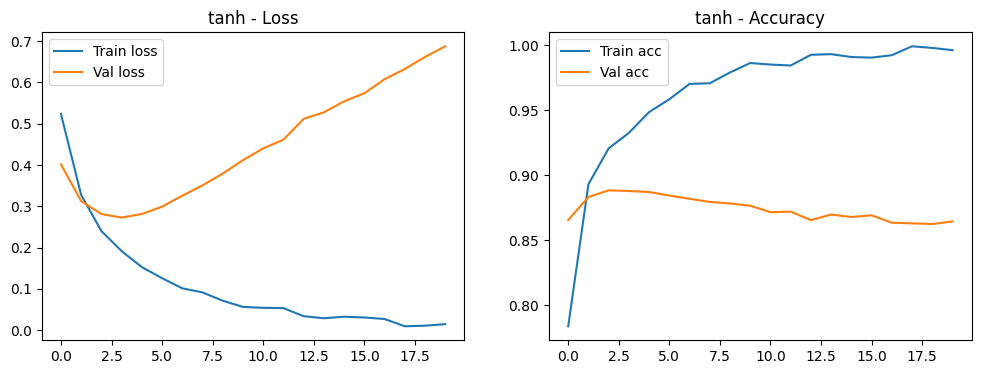

In [ ]:
model_tanh = keras.Sequential([
    layers.Dense(16, activation="tanh", input_shape=(10000,)),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])

model_tanh.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: tanh Activation")
history_tanh = model_tanh.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

best_val_acc_tanh = max(history_tanh.history["val_accuracy"])
best_epoch_tanh = history_tanh.history["val_accuracy"].index(best_val_acc_tanh) + 1
print(f"\nBest Val Acc (tanh): {best_val_acc_tanh:.4f} (Epoch {best_epoch_tanh})")


test_loss_tanh, test_acc_tanh = model_tanh.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc (tanh): {test_acc_tanh:.4f}")
print(f"Test Loss (tanh): {test_loss_tanh:.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_tanh.history["loss"], label="Train loss")
plt.plot(history_tanh.history["val_loss"], label="Val loss")
plt.title("tanh - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tanh.history["accuracy"], label="Train acc")
plt.plot(history_tanh.history["val_accuracy"], label="Val acc")
plt.title("tanh - Accuracy")
plt.legend()

plt.show()

5.Use any technique we studied in class, and these include regularization, dropout, etc., to
get your model to perform better on validation.


Training: Dropout 0.5
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.5706 - loss: 0.6725 - val_accuracy: 0.8356 - val_loss: 0.5285
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7474 - loss: 0.5476 - val_accuracy: 0.8682 - val_loss: 0.4149
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8095 - loss: 0.4556 - val_accuracy: 0.8774 - val_loss: 0.3538
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8514 - loss: 0.3876 - val_accuracy: 0.8864 - val_loss: 0.3063
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8740 - loss: 0.3395 - val_accuracy: 0.8884 - val_loss: 0.2873
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9020 - loss: 0.2951 - val_accuracy: 0.8890 - val_loss: 0.2758
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9120 - loss: 0.2681 - val_accuracy: 0.8880 - val_loss: 0.2775
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9233 - loss: 0.2321 - va

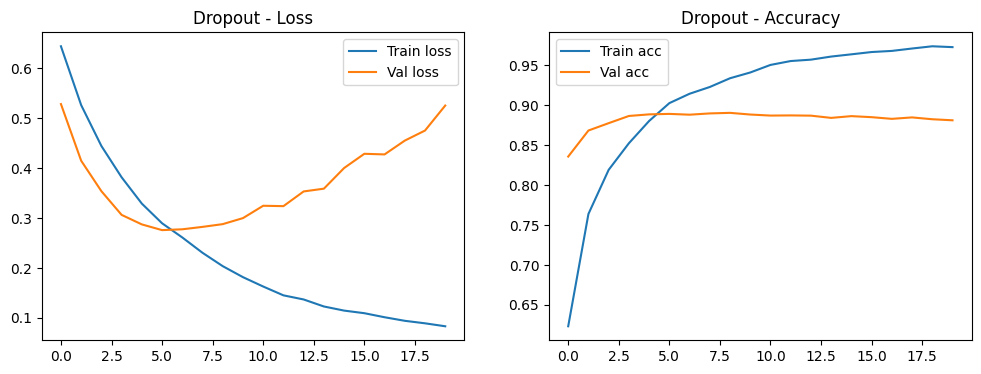

In [ ]:
model_dropout = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_dropout.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training: Dropout 0.5")
history_dropout = model_dropout.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)


best_val_acc_dropout = max(history_dropout.history["val_accuracy"])
best_epoch_dropout = history_dropout.history["val_accuracy"].index(best_val_acc_dropout) + 1
print(f"\nBest Val Acc (Dropout): {best_val_acc_dropout:.4f} (Epoch {best_epoch_dropout})")


test_loss_dropout, test_acc_dropout = model_dropout.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test Acc (Dropout): {test_acc_dropout:.4f}")
print(f"Test Loss (Dropout): {test_loss_dropout:.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_dropout.history["loss"], label="Train loss")
plt.plot(history_dropout.history["val_loss"], label="Val loss")
plt.title("Dropout - Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dropout.history["accuracy"], label="Train acc")
plt.plot(history_dropout.history["val_accuracy"], label="Val acc")
plt.title("Dropout - Accuracy")
plt.legend()

plt.show()

# FINAL MASTER COMPARISION FOR EVERY MODEL



FINAL MODEL COMPARISON 

              Model  Best_Val_Acc  Test_Acc  Overfitting_Gap
       Q5 - Dropout        0.8903   0.87140          0.01890
Q1 - 3 Layers (16u)        0.8891   0.85408          0.03502
Q1 - 2 Layers (16u)        0.8886   0.85572          0.03288
          Q4 - tanh        0.8885   0.85336          0.03514
Q2 - 2 Layers (64u)        0.8880   0.86280          0.02520
Q2 - 2 Layers (32u)        0.8876   0.85816          0.02944
      Q3 - MSE Loss        0.8876   0.86160          0.02600
 Q1 - 1 Layer (16u)        0.8871   0.86468          0.02242

 BEST MODEL SELECTED 

Model: Q5 - Dropout
Validation Accuracy: 0.8903
Test Accuracy: 0.8714
Overfitting Gap: 0.0189


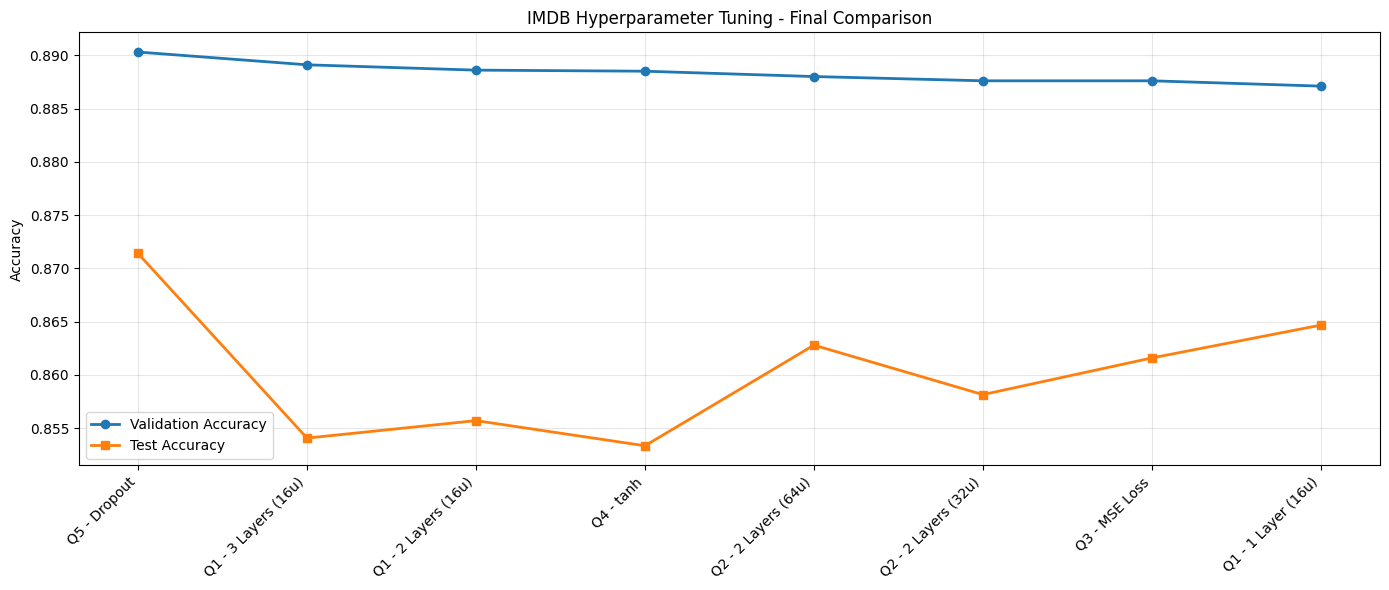

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


comparison = pd.DataFrame([


    ["Q1 - 1 Layer (16u)", best_val_acc_1, test_acc_1],
    ["Q1 - 2 Layers (16u)", best_val_acc_2, test_acc_2],
    ["Q1 - 3 Layers (16u)", best_val_acc_3, test_acc_3],


    ["Q2 - 2 Layers (32u)", best_val_acc_32, test_acc_32],
    ["Q2 - 2 Layers (64u)", best_val_acc_64, test_acc_64],

    ["Q3 - MSE Loss", best_val_acc_mse, test_acc_mse],


    ["Q4 - tanh", best_val_acc_tanh, test_acc_tanh],


    ["Q5 - Dropout", best_val_acc_dropout, test_acc_dropout],

], columns=["Model", "Best_Val_Acc", "Test_Acc"])


comparison["Overfitting_Gap"] = comparison["Best_Val_Acc"] - comparison["Test_Acc"]


comparison = comparison.sort_values("Best_Val_Acc", ascending=False).reset_index(drop=True)

print("\nFINAL MODEL COMPARISON \n")
print(comparison.to_string(index=False))


best_model = comparison.iloc[0]

print("\n BEST MODEL SELECTED \n")
print(f"Model: {best_model['Model']}")
print(f"Validation Accuracy: {best_model['Best_Val_Acc']:.4f}")
print(f"Test Accuracy: {best_model['Test_Acc']:.4f}")
print(f"Overfitting Gap: {best_model['Overfitting_Gap']:.4f}")

models = comparison["Model"]
val_acc = comparison["Best_Val_Acc"]
test_acc = comparison["Test_Acc"]

x = np.arange(len(models))

plt.figure(figsize=(14,6))

plt.plot(x, val_acc, marker='o', linewidth=2, label="Validation Accuracy")
plt.plot(x, test_acc, marker='s', linewidth=2, label="Test Accuracy")

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("IMDB Hyperparameter Tuning - Final Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
